In [135]:
import numpy as np
from matplotlib import pyplot as plt
from tqdm.notebook import tqdm
# from numba import njit

G = 6.6743e-11
M_SUN = 1.988416e30
M_EARTH = 5.97217e24
AU = 1.495978707e11
YR = np.sqrt(4 * np.pi**2 * AU**3 / (G * (M_EARTH + M_SUN)))

## Solver

In [136]:
# @njit
def RK4(f, x0, t0, tf, N):
    """
    RK4 method.
    f: NumPy function with call signature f(t, x)
    x0: initial condition (np.ndarray of shape (len(x0),))
    t0: initial time (float)
    tf: final time (float)
    N: number of time steps (int)
    Returns: x (np.ndarray of shape (N + 1, len(x0)))
    """
    t = np.linspace(t0, tf, N + 1)
    x = np.zeros([N + 1] + list(x0.shape))
    h = (tf - t0) / N
    x[0] = x0
    for i in tqdm(range(N)):
        k1 = f(t[i], x[i])
        k2 = f(t[i] + h / 2, x[i] + h * k1 / 2)
        k3 = f(t[i] + h / 2, x[i] + h * k2 / 2)
        k4 = f(t[i] + h, x[i] + h * k3)
        x[i + 1] = x[i] + (h / 6) * (k1 + 2 * k2 + 2 * k3 + k4)
    return x

In [137]:
# @njit
def n_body(m, x0, v0, tf, N):
    """
    N-body integrator using RK4.
    m: masses (np.ndarray of shape (n,))
    x0: initial positions (np.ndarray of shape (n, D))
    v0: initial velocities (np.ndarray of shape (n, D))
    tf: final time (float)
    N: number of time steps (int)
    Returns: concatenated x and v (np.ndarray of shape (N + 1, 2*n, D))
    """
    n, D = x0.shape
    def f(_, y):
        """
        y: concatenated x and v (np.ndarray of shape (2n, D))
        """
        dy = np.zeros_like(y)
        dy[:n] = y[n:]
        x = y[:n]
        for i in range(n):
            x_red = np.delete(x, i, 0)
            m_red = np.delete(m, i)
            dy[n + i] = G * np.sum((m_red / np.linalg.norm(x_red - x[i], axis = 1)**3)[:, np.newaxis] * (x_red - x[i]), axis = 0)
        return dy
    return RK4(f, np.concatenate((x0, v0), axis = 0), 0, tf, N)

## Results
### Equal Masses

In [138]:
r = AU
m = np.array([M_SUN, M_SUN])
x0 = np.array([[r / 2, 0], [-r / 2, 0]])
v0 = np.array([[0, np.sqrt(G * m[1]**2 / ((m[0] + m[1]) * r))], [0, -np.sqrt(G * m[0]**2 / ((m[0] + m[1]) * r))]])
tf = 2 * np.sqrt(4 * np.pi**2 * r**3 / (G * (m[0] + m[1])))
N = 10000
sol = n_body(np.array(m), x0, v0, tf, N)
sol_x = sol[:, :len(m), :]
sol_v = sol[:, len(m):, :]
t = np.linspace(0, tf, N + 1)

r0 = np.average(x0, axis = 0, weights = m)
r_sim = np.linalg.norm(sol_x - r0[np.newaxis, np.newaxis, :], axis = 2)

r_final = r_sim[-1]
r_exp = r * m[::-1] / np.sum(m)
r_err = np.abs(r_final - r_exp) / r_exp
print("Final orbital radii: ", r_final)
print("Expected orbital radii: ", r_exp)
print("Relative error: ", r_err)

  0%|          | 0/10000 [00:00<?, ?it/s]

Final orbital radii:  [7.47989354e+10 7.47989354e+10]
Expected orbital radii:  [7.47989354e+10 7.47989354e+10]
Relative error:  [2.85596374e-15 2.85596374e-15]


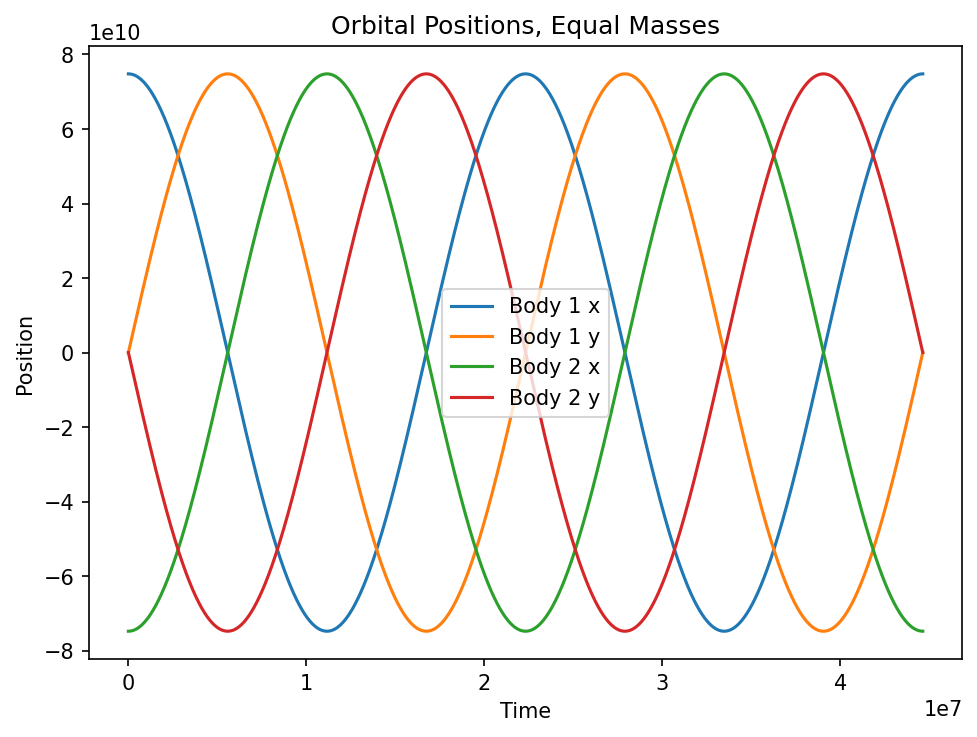

In [139]:
fig, ax = plt.subplots(dpi = 150, layout = "constrained")
plt.plot(t, sol_x[:, 0, 0], label = "Body 1 x")
plt.plot(t, sol_x[:, 0, 1], label = "Body 1 y")
plt.plot(t, sol_x[:, 1, 0], label = "Body 2 x")
plt.plot(t, sol_x[:, 1, 1], label = "Body 2 y")
plt.xlabel("Time")
plt.ylabel("Position")
plt.title("Orbital Positions, Equal Masses")
plt.legend()

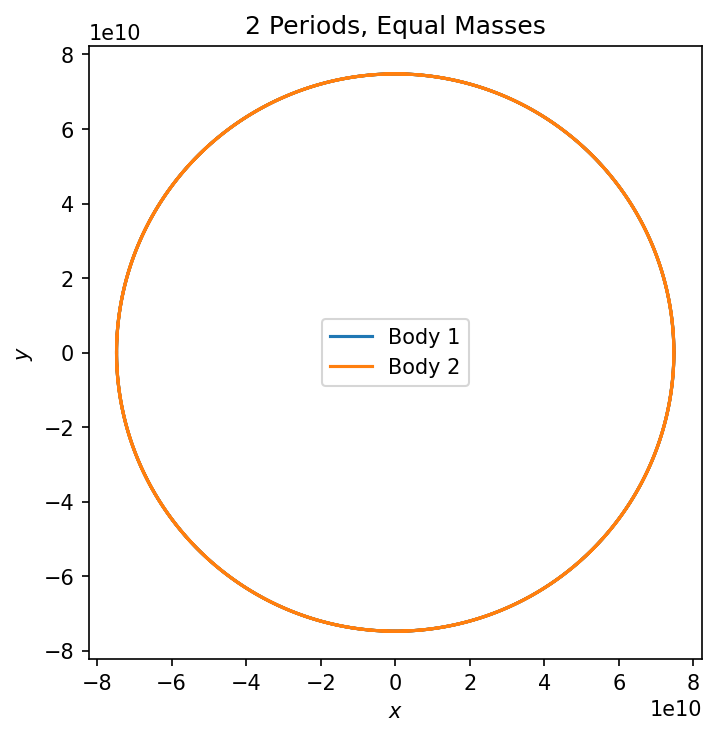

In [140]:
fig, ax = plt.subplots(dpi = 150, layout = "constrained")
ax.set_aspect("equal")
plt.plot(sol_x[:, 0, 0], sol_x[:, 0, 1], label = "Body 1")
plt.plot(sol_x[:, 1, 0], sol_x[:, 1, 1], label = "Body 2")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title("2 Periods, Equal Masses")
plt.legend()

### Unequal Masses

In [141]:
r = AU
m = np.array([M_EARTH, M_SUN])
x0 = np.array([[r / 2, 0], [-r / 2, 0]])
v0 = np.array([[0, np.sqrt(G * m[1]**2 / ((m[0] + m[1]) * r))], [0, -np.sqrt(G * m[0]**2 / ((m[0] + m[1]) * r))]])
tf = 2 * np.sqrt(4 * np.pi**2 * r**3 / (G * (m[0] + m[1])))
N = 10000
sol = n_body(np.array(m), x0, v0, tf, N)
sol_x = sol[:, :len(m), :]
sol_v = sol[:, len(m):, :]
t = np.linspace(0, tf, N + 1)

r0 = np.average(x0, axis = 0, weights = m)
r_sim = np.linalg.norm(sol_x - r0[np.newaxis, np.newaxis, :], axis = 2)

r_final = r_sim[-1]
r_exp = r * m[::-1] / np.sum(m)
r_err = np.abs(r_final - r_exp) / r_exp
print("Final orbital radii: ", r_final)
print("Expected orbital radii: ", r_exp)
print("Relative error: ", r_err)

  0%|          | 0/10000 [00:00<?, ?it/s]

Final orbital radii:  [1.49597421e+11 4.49313037e+05]
Expected orbital radii:  [1.49597421e+11 4.49313037e+05]
Relative error:  [1.34638695e-14 3.71556974e-12]


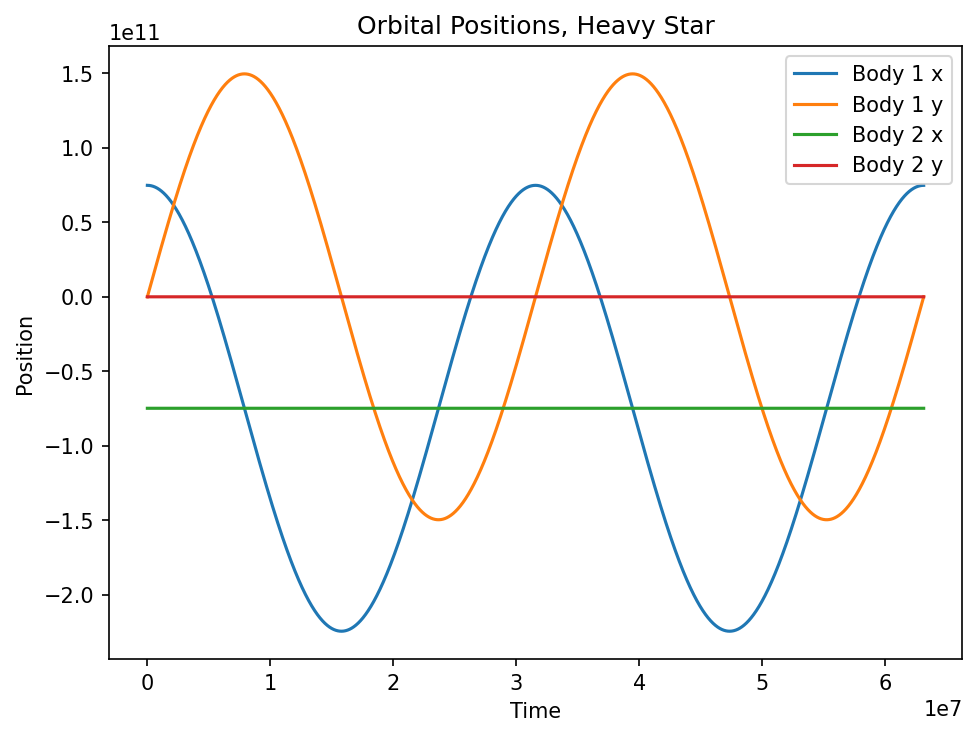

In [142]:
fig, ax = plt.subplots(dpi = 150, layout = "constrained")
plt.plot(t, sol_x[:, 0, 0], label = "Body 1 x")
plt.plot(t, sol_x[:, 0, 1], label = "Body 1 y")
plt.plot(t, sol_x[:, 1, 0], label = "Body 2 x")
plt.plot(t, sol_x[:, 1, 1], label = "Body 2 y")
plt.xlabel("Time")
plt.ylabel("Position")
plt.title("Orbital Positions, Heavy Star")
plt.legend()

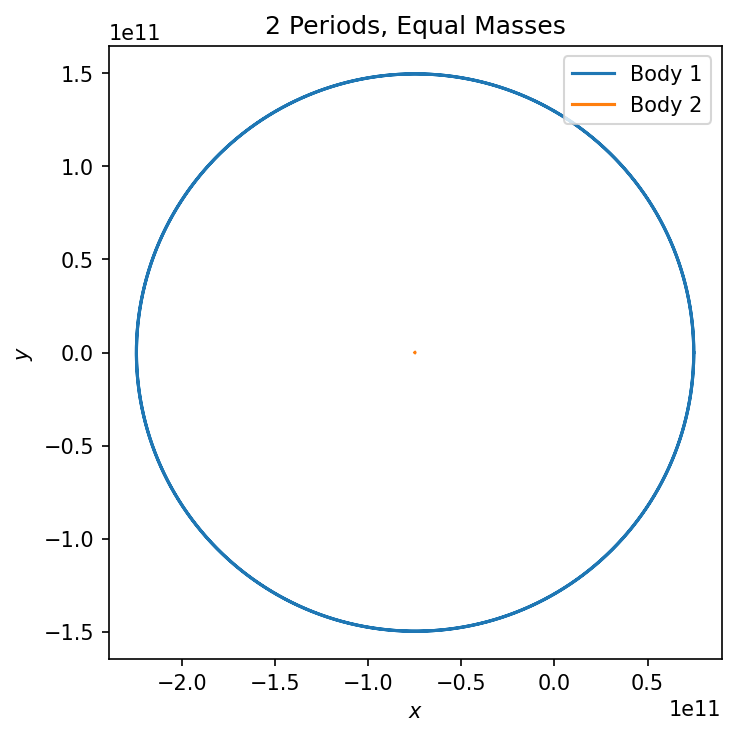

In [143]:
fig, ax = plt.subplots(dpi = 150, layout = "constrained")
ax.set_aspect("equal")
plt.plot(sol_x[:, 0, 0], sol_x[:, 0, 1], label = "Body 1")
plt.plot(sol_x[:, 1, 0], sol_x[:, 1, 1], label = "Body 2")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title("2 Periods, Equal Masses")
plt.legend()

### Convergence diagnostics

In [144]:
orbits = 100

r = AU
m = np.array([M_SUN, M_SUN])
x0 = np.array([[r / 2, 0], [-r / 2, 0]])
v0 = np.array([[0, np.sqrt(G * m[1]**2 / ((m[0] + m[1]) * r))], [0, -np.sqrt(G * m[0]**2 / ((m[0] + m[1]) * r))]])
tf = orbits * np.sqrt(4 * np.pi**2 * r**3 / (G * (m[0] + m[1])))
N = orbits * 500
sol = n_body(np.array(m), x0, v0, tf, N)
sol_x = sol[:, :len(m), :]
sol_v = sol[:, len(m):, :]
t = np.linspace(0, tf, N + 1)

r0 = np.average(x0, axis = 0, weights = m)
r_sim = np.linalg.norm(sol_x - r0[np.newaxis, np.newaxis, :], axis = 2)

r_final = r_sim[-1]
r_exp = r * m[::-1] / np.sum(m)
r_err = np.abs(r_final - r_exp) / r_exp
print("Final orbital radii: ", r_final)
print("Expected orbital radii: ", r_exp)
print("Relative error: ", r_err)

  0%|          | 0/50000 [00:00<?, ?it/s]

Final orbital radii:  [7.47989349e+10 7.47989349e+10]
Expected orbital radii:  [7.47989354e+10 7.47989354e+10]
Relative error:  [5.46942147e-09 5.46942147e-09]


Text(0.5, 1.0, '100 Orbits, Equal Masses')

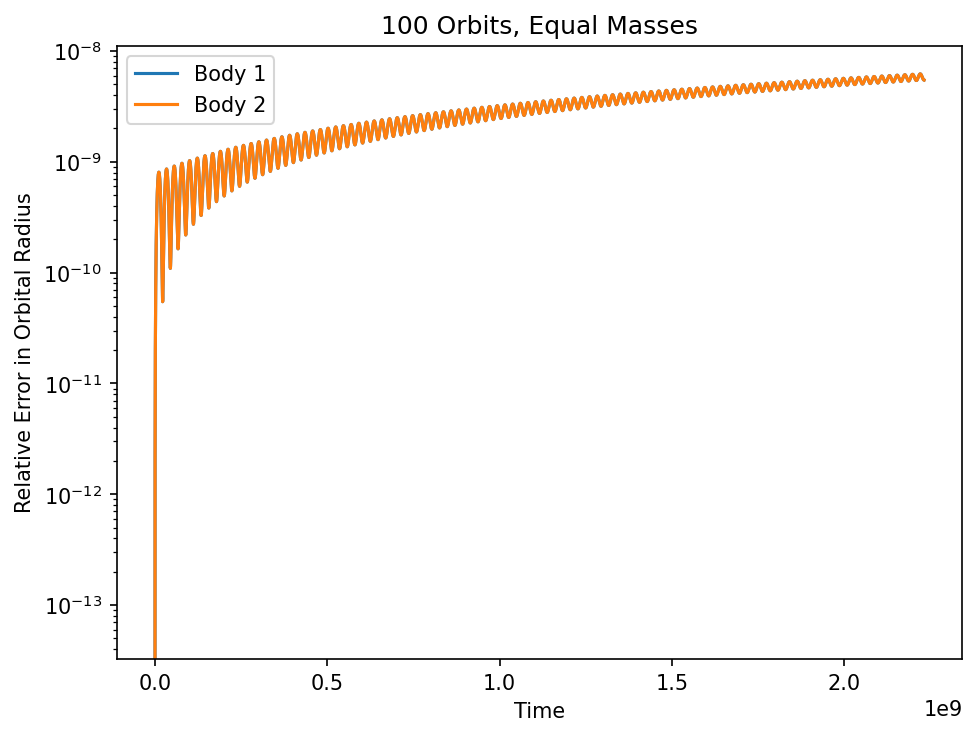

In [145]:
r_errs = np.abs(r_sim - r_exp) / r_exp
fig, ax = plt.subplots(dpi = 150, layout = "constrained")
plt.plot(t, r_errs[:,0], label = "Body 1")
plt.plot(t, r_errs[:,1], label = "Body 2")
plt.xlabel("Time")
plt.ylabel("Relative Error in Orbital Radius")
plt.yscale("log")
plt.legend()
plt.title(f"{orbits} Orbits, Equal Masses")

In [146]:
orbits = 100

r = AU
m = np.array([M_EARTH, M_SUN])
x0 = np.array([[r / 2, 0], [-r / 2, 0]])
v0 = np.array([[0, np.sqrt(G * m[1]**2 / ((m[0] + m[1]) * r))], [0, -np.sqrt(G * m[0]**2 / ((m[0] + m[1]) * r))]])
tf = orbits * np.sqrt(4 * np.pi**2 * r**3 / (G * (m[0] + m[1])))
N = orbits * 500
sol = n_body(np.array(m), x0, v0, tf, N)
sol_x = sol[:, :len(m), :]
sol_v = sol[:, len(m):, :]
t = np.linspace(0, tf, N + 1)

r0 = np.average(x0, axis = 0, weights = m)
r_sim = np.linalg.norm(sol_x - r0[np.newaxis, np.newaxis, :], axis = 2)

r_final = r_sim[-1]
r_exp = r * m[::-1] / np.sum(m)
r_err = np.abs(r_final - r_exp) / r_exp
print("Final orbital radii: ", r_final)
print("Expected orbital radii: ", r_exp)
print("Relative error: ", r_err)

  0%|          | 0/50000 [00:00<?, ?it/s]

Final orbital radii:  [1.49597421e+11 4.49313035e+05]
Expected orbital radii:  [1.49597421e+11 4.49313037e+05]
Relative error:  [5.4694122e-09 5.4595756e-09]


Text(0.5, 1.0, '100 Orbits, Equal Masses')

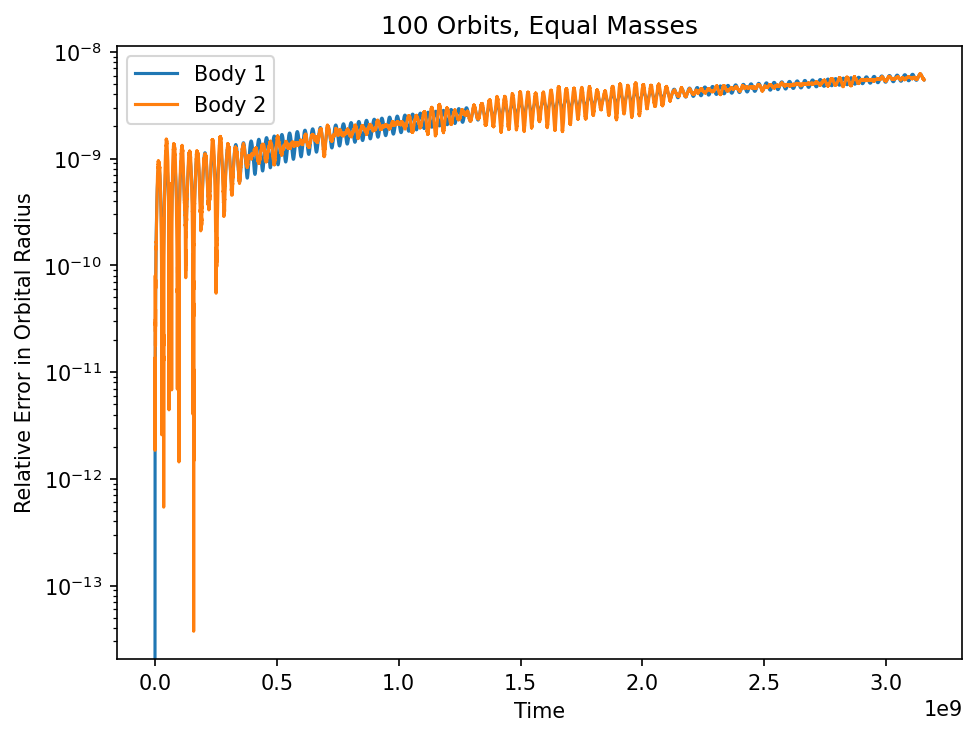

In [147]:
r_errs = np.abs(r_sim - r_exp) / r_exp
fig, ax = plt.subplots(dpi = 150, layout = "constrained")
plt.plot(t, r_errs[:,0], label = "Body 1")
plt.plot(t, r_errs[:,1], label = "Body 2")
plt.xlabel("Time")
plt.ylabel("Relative Error in Orbital Radius")
plt.yscale("log")
plt.legend()
plt.title(f"{orbits} Orbits, Equal Masses")

### Fun

  0%|          | 0/2500 [00:00<?, ?it/s]

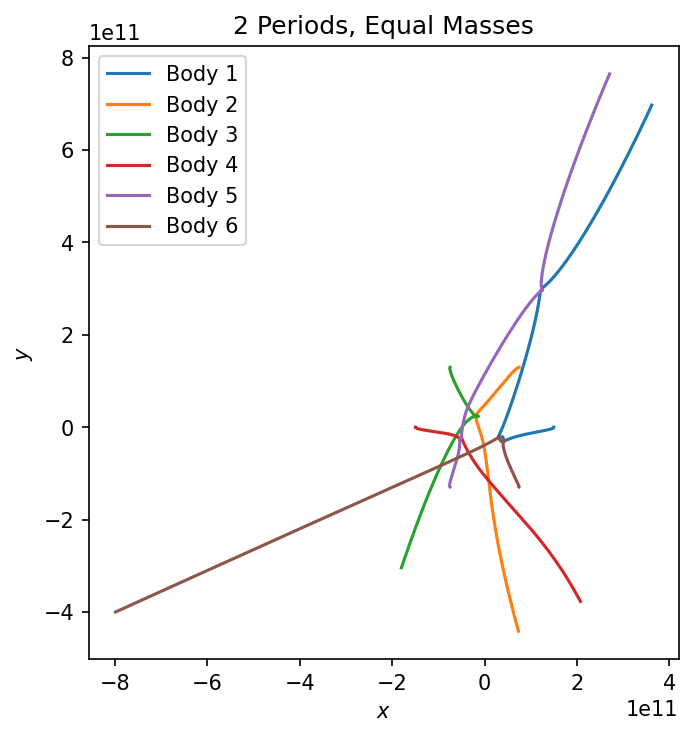

In [182]:
n_bodies = 6
yrs = 0.25
# m = M_SUN * np.random.rand(n_bodies)
m = M_SUN * np.ones(n_bodies)
angles = np.linspace(0, 2 * np.pi, n_bodies, endpoint = False)

x0 = AU * np.stack([np.cos(angles), np.sin(angles)], axis = 1)
v0 = AU / YR * (2 * np.random.rand(n_bodies, 2) - 1) * 1
tf = YR * yrs
N = 10000 * yrs
sol = n_body(np.array(m), x0, v0, tf, int(N))
sol_x = sol[:, :len(m), :]
sol_v = sol[:, len(m):, :]
t = np.linspace(0, tf, int(N) + 1)

fig, ax = plt.subplots(dpi = 150, layout = "constrained")
ax.set_aspect("equal")
for i in range(n_bodies):
    plt.plot(sol_x[:, i, 0], sol_x[:, i, 1], label = f"Body {i + 1}")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title("{n_bodies} Bodies, Equal Masses")
plt.legend()